In [4]:
import pandas as pd

#load datasets
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Translation:", translation.shape)

Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Translation: (71, 2)


In [5]:
# Story 1 - Join all tables into one master dataset

# Join orders + reviews
df = orders.merge(reviews, on='order_id', how='left')

# Join with customers
df = df.merge(customers, on='customer_id', how='left')

# Join with products (via order items)
order_items = pd.read_csv('olist_order_items_dataset.csv')
df = df.merge(order_items, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')

# Join with translation (bonus - English category names)
df = df.merge(translation, on='product_category_name', how='left')

# ✅ Check for duplicate rows
print("Total rows:", len(df))
print("Unique order_ids:", df['order_id'].nunique())
print("Duplicate rows:", df.duplicated().sum())

print("\nMaster dataset shape:", df.shape)
print("\nSample:")
df.head()

Total rows: 114092
Unique order_ids: 99441
Duplicate rows: 0

Master dataset shape: (114092, 33)

Sample:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [6]:
# Story 2 : Calculate delivery delays

# Convert date columns to datetime
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Calculate Days_Difference (positive = delivered before estimate = on time)
df['Days_Difference'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

# Exclude cancelled/unavailable orders
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Classify orders
def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

df_delivered['delivery_status'] = df_delivered['Days_Difference'].apply(classify_delivery)

# Summary
print(df_delivered['delivery_status'].value_counts())
print("\nTotal delivered orders:", len(df_delivered))

delivery_status
On Time       102077
Super Late      4690
Late            4073
Name: count, dtype: int64

Total delivered orders: 110840


   customer_state  total_orders  late_orders  late_percentage
1              AL           431          104            24.13
9              MA           805          163            20.25
24             SE           375           61            16.27
16             PI           524           81            15.46
5              CE          1431          219            15.30
4              BA          3703          508            13.72
18             RJ         14224         1846            12.98
13             PA          1061          131            12.35
26             TO           310           38            12.26
7              ES          2236          273            12.21


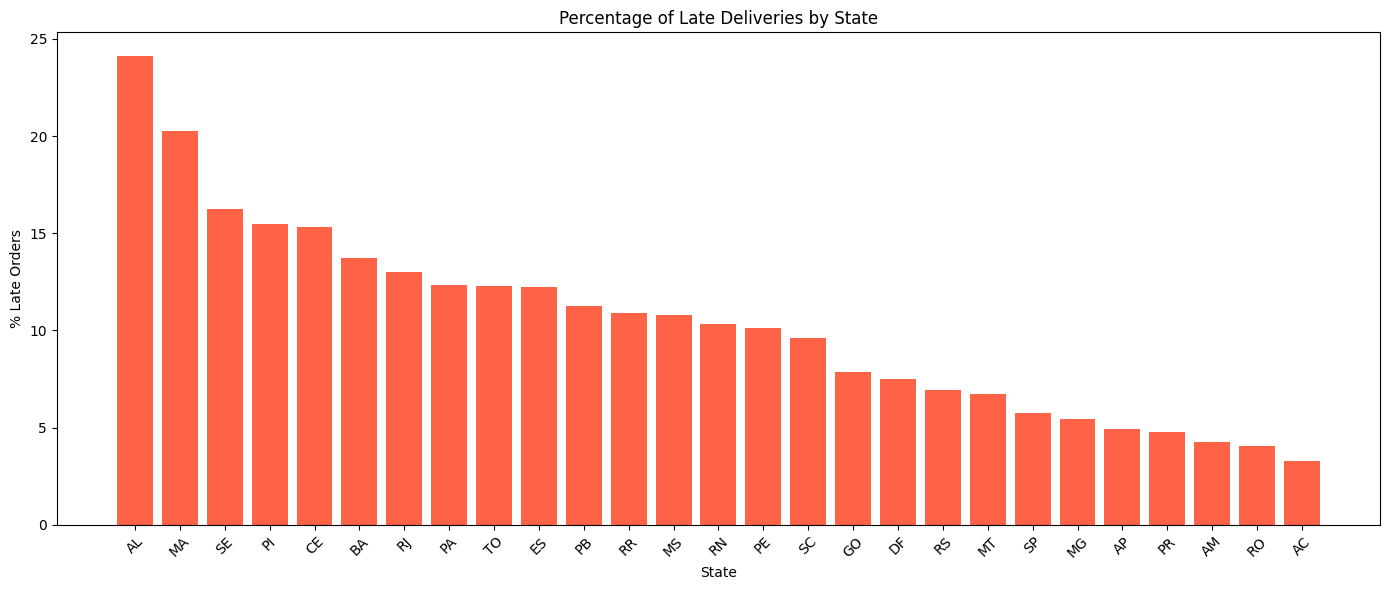

In [7]:
# Story 3 - Late deliveries by State

import matplotlib.pyplot as plt

# Calculate late orders per state
state_stats = df_delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

# Calculate percentage of late orders
state_stats['late_percentage'] = (state_stats['late_orders'] / state_stats['total_orders'] * 100).round(2)

# Sort by late percentage
state_stats = state_stats.sort_values('late_percentage', ascending=False)

print(state_stats.head(10))

# Plot
plt.figure(figsize=(14, 6))
plt.bar(state_stats['customer_state'], state_stats['late_percentage'], color='tomato')
plt.title('Percentage of Late Deliveries by State')
plt.xlabel('State')
plt.ylabel('% Late Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Review Score by Delivery Status:
delivery_status
Late          3.42
On Time       4.21
Super Late    1.78
Name: review_score, dtype: float64


/tmp/ipykernel_1469/3309967880.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sentiment['delay_bin'] = pd.cut(


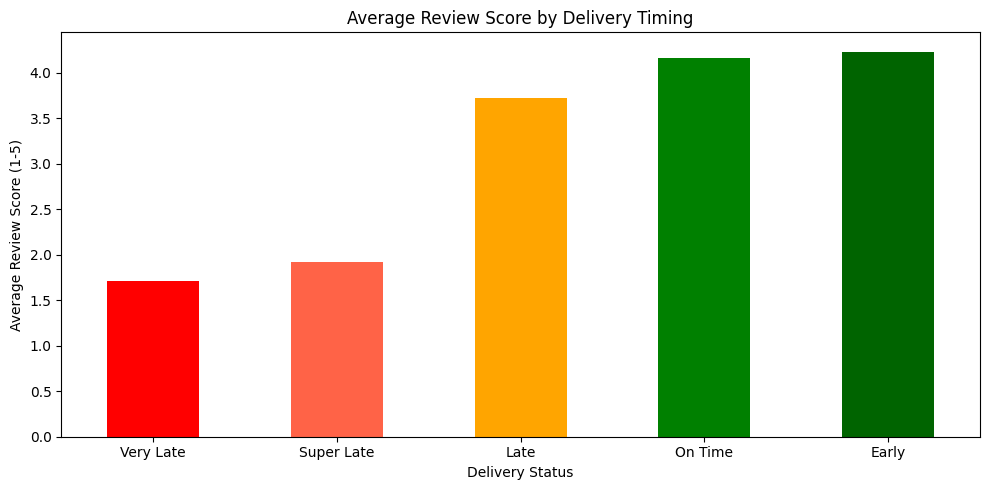

In [8]:
# Story 4 - Delay vs Review Score

# Drop rows with missing review scores or days difference
df_sentiment = df_delivered.dropna(subset=['review_score', 'Days_Difference'])

# Average review score by delivery status
avg_score = df_sentiment.groupby('delivery_status')['review_score'].mean().round(2)
print("Average Review Score by Delivery Status:")
print(avg_score)

# Bin the delay days for visualization
df_sentiment['delay_bin'] = pd.cut(
    df_sentiment['Days_Difference'],
    bins=[-999, -15, -5, 0, 7, 999],
    labels=['Very Late', 'Super Late', 'Late', 'On Time', 'Early']
)

avg_by_bin = df_sentiment.groupby('delay_bin', observed=True)['review_score'].mean().round(2)

# Plot
plt.figure(figsize=(10, 5))
avg_by_bin.plot(kind='bar', color=['red', 'tomato', 'orange', 'green', 'darkgreen'])
plt.title('Average Review Score by Delivery Timing')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score (1-5)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

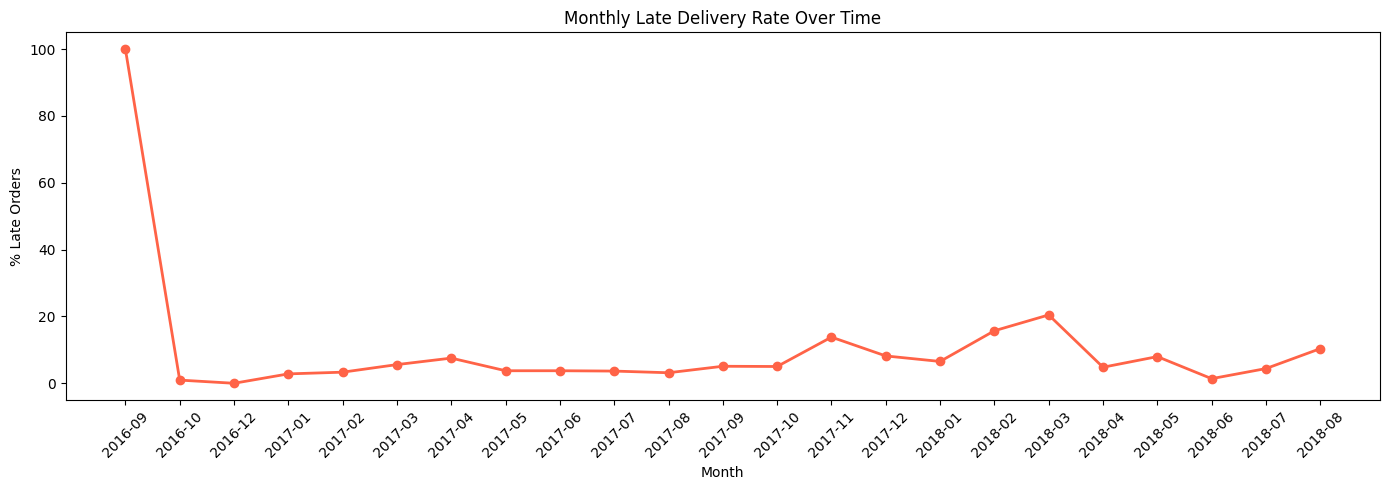

In [9]:
# Candidate's Choice - Monthly Late Delivery Trend

df_delivered['order_purchase_timestamp'] = pd.to_datetime(df_delivered['order_purchase_timestamp'])
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly = df_delivered.groupby('month').agg(
    total=('order_id', 'count'),
    late=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

monthly['late_pct'] = (monthly['late'] / monthly['total'] * 100).round(2)
monthly['month'] = monthly['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['month'], monthly['late_pct'], marker='o', color='tomato', linewidth=2)
plt.title('Monthly Late Delivery Rate Over Time')
plt.xlabel('Month')
plt.ylabel('% Late Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# Export cleaned data for dashboard
df_delivered.to_csv('olist_clean.csv', index=False)
state_stats.to_csv('state_stats.csv', index=False)
monthly.to_csv('monthly_stats.csv', index=False)

print("Files exported successfully!")

Files exported successfully!


In [11]:
sentiment_summary = df_delivered.groupby('delivery_status')['review_score'].mean().round(2).reset_index()
sentiment_summary.columns = ['delivery_status', 'avg_review_score']
sentiment_summary.to_csv('sentiment_summary.csv', index=False)